# MAGPIE — May 2026 Demo

Run cells top to bottom. **Cell 1** starts all nodes. **Cell 2** makes rclpy importable in VS Code.

Set `OBJECT` in Cell 3 to the thing on the table, e.g. `'red block'`.

In [1]:
import subprocess, os, time

SAM3_PY  = os.path.expanduser('~/sam3_env/bin/python3')
SAM3_SCR = os.path.expanduser('~/magpie_control/scripts/sam3_infer.py')
ROS      = 'source /opt/ros/humble/setup.bash && source ~/ws_ctrl/install/setup.bash'

def ros_proc(cmd, log):
    open(log, 'w').close()
    return subprocess.Popen(f'{ROS} && {cmd}', shell=True, executable='/bin/bash',
                            stdout=open(log, 'a'), stderr=subprocess.STDOUT)

print('Killing stale processes...')
for p in ['ur5_node', 'gripper_node', 'realsense2_camera', 'sam3_infer']:
    subprocess.run(f'pkill -9 -f {p}', shell=True)
subprocess.run('rm -f /tmp/sam3.sock', shell=True)
time.sleep(3)

PROCS = {}
PROCS['ur5']     = ros_proc('ros2 run magpie_control ur5_node',     '/tmp/log_ur5.txt')
PROCS['gripper'] = ros_proc('ros2 run magpie_control gripper_node', '/tmp/log_gripper.txt')
PROCS['camera']  = ros_proc(
    'ros2 run realsense2_camera realsense2_camera_node --ros-args -r __ns:=/camera/gripper_camera',
    '/tmp/log_camera.txt')
PROCS['sam3']    = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket'],
    stdout=open('/tmp/log_sam3.txt', 'w'), stderr=subprocess.STDOUT)

print('Waiting for SAM3 (up to 90s)...')
for i in range(90):
    time.sleep(1)
    if os.path.exists('/tmp/sam3.sock'):
        print(f'  SAM3 ready after {i+1}s')
        break
    if PROCS['sam3'].poll() is not None:
        print('  SAM3 crashed:'); print(open('/tmp/log_sam3.txt').read()[-600:])
        break
    if (i+1) % 20 == 0:
        print(f'  {i+1}s...')

time.sleep(3)
print()
for n, p in PROCS.items():
    status = 'OK' if p.poll() is None else f'EXITED  -> tail /tmp/log_{n}.txt'
    print(f'  {n:<10} {status}')

Killing stale processes...
Waiting for SAM3 (up to 90s)...
  SAM3 ready after 14s

  ur5        OK
  gripper    OK
  camera     OK
  sam3       OK


In [2]:
# Load ROS shared libraries so rclpy imports in any VS Code kernel
import sys, os, ctypes, glob

for _d in [
    '/opt/ros/humble/lib/x86_64-linux-gnu',
    '/opt/ros/humble/lib',
    '/home/user/ws_ctrl/install/magpie_msgs/lib',
    '/home/user/ws_ctrl/install/magpie_control/lib',
]:
    for _so in sorted(glob.glob(_d + '/*.so*')):
        try:
            ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

for _p in [
    '/opt/ros/humble/local/lib/python3.10/dist-packages',
    '/opt/ros/humble/lib/python3.10/site-packages',
    '/home/user/ws_ctrl/install/magpie_msgs/local/lib/python3.10/dist-packages',
    '/home/user/ws_ctrl/install/magpie_control/lib/python3.10/site-packages',
    '/home/user/.local/lib/python3.10/site-packages',
    '/home/user/magpie_control/src',
    '/home/user/magpie_control/scripts',
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import rclpy
print('rclpy OK')

         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp
         at line 253 in /opt/ros/humble/include/class_loader/class_loader/class_loader_core.hpp


rclpy OK


In [3]:
import time, re, json, tempfile, base64, socket as _sock
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import cv2
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 80   # keeps output file size small for GitHub

from rclpy.node import Node
from rclpy.qos import QoSProfile, ReliabilityPolicy, DurabilityPolicy
from sensor_msgs.msg import Image as RosImage, CameraInfo
from geometry_msgs.msg import PoseStamped, Pose
from std_srvs.srv import Trigger
from cv_bridge import CvBridge
from magpie_msgs.msg import GripperState
from magpie_msgs.srv import MoveLinear, SetGripperForce, SetGripperPosition
from magpie_control import poses
from magpie_control.homog_utils import homog_xform, R_krot
from magpie_control.gripper_arc import fingertip_drop
from google import genai
from google.genai import types as gtypes
from pointcloud_utils import build_segmented_pcd, denoise_pcd, analyse_pcd

# --- CONFIG ---
OBJECT         = 'red block'
SAM3_SOCK      = '/tmp/sam3.sock'
GEMINI_KEY     = os.environ.get('GEMINI_API_KEY', '')
GRIPPER_LEN    = 0.231
HARD_FLOOR_Z   = 0.030
APPROACH_H     = 0.10
_TCP_TO_CAM    = homog_xform(R_krot([0, 0, 1], -np.pi/2), [0, 0, 0.120])

if not GEMINI_KEY:
    print('WARNING: GEMINI_API_KEY not set.')
print('Imports OK')

Imports OK


In [4]:
# Helper: quaternion <-> rotation vector
def _quat_to_rv(w, x, y, z):
    a = 2.0 * np.arccos(np.clip(w, -1, 1))
    s = np.sin(a / 2)
    return np.zeros(3) if s < 1e-10 else a * np.array([x, y, z]) / s

def _rv_to_quat(rv):
    a = np.linalg.norm(rv)
    if a < 1e-10:
        return (1., 0., 0., 0.)
    ax = rv / a
    return (np.cos(a/2), ax[0]*np.sin(a/2), ax[1]*np.sin(a/2), ax[2]*np.sin(a/2))

def _mat_to_pose(mat):
    v = poses.pose_mtrx_to_vec(np.array(mat))
    w, x, y, z = _rv_to_quat(np.array(v[3:]))
    p = Pose()
    p.position.x, p.position.y, p.position.z = v[0], v[1], v[2]
    p.orientation.w, p.orientation.x = w, x
    p.orientation.y, p.orientation.z = y, z
    return p

# QoS profiles matching RealSense D405 publisher settings
img_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.TRANSIENT_LOCAL)
inf_qos = QoSProfile(depth=1, reliability=ReliabilityPolicy.RELIABLE,
                     durability=DurabilityPolicy.VOLATILE)

class Demo(Node):
    def __init__(self):
        super().__init__('magpie_demo')
        self.bridge = CvBridge()
        self.color = self.depth = self.caminfo = self.tcp = self.gs = None
        NS = '/camera/gripper_camera/camera'
        self.create_subscription(
            RosImage,    NS+'/color/image_raw',
            lambda m: setattr(self, 'color', self.bridge.imgmsg_to_cv2(m, 'rgb8')), img_qos)
        self.create_subscription(
            RosImage,    NS+'/depth/image_rect_raw',
            lambda m: setattr(self, 'depth', self.bridge.imgmsg_to_cv2(m, 'passthrough')), img_qos)
        self.create_subscription(
            CameraInfo,  NS+'/color/camera_info',
            lambda m: setattr(self, 'caminfo', m), inf_qos)
        self.create_subscription(
            GripperState, '/gripper/state',
            lambda m: setattr(self, 'gs', m), 1)
        self.create_subscription(
            PoseStamped, '/arm/tcp_pose',
            self._tcp_cb, 1)
        self.mv  = self.create_client(MoveLinear,         '/arm/move_l')
        self.tch = self.create_client(Trigger,             '/arm/teach_mode')
        self.opn = self.create_client(Trigger,             '/gripper/open')
        self.cls = self.create_client(Trigger,             '/gripper/close')
        self.frc = self.create_client(SetGripperForce,     '/gripper/set_force')
        self.pos = self.create_client(SetGripperPosition,  '/gripper/set_position')

    def _tcp_cb(self, m):
        p = m.pose
        rv = _quat_to_rv(p.orientation.w, p.orientation.x, p.orientation.y, p.orientation.z)
        self.tcp = poses.pose_vec_to_mtrx([p.position.x, p.position.y, p.position.z, *rv])

    def spin(self, n=10, t=0.15):
        for _ in range(n):
            rclpy.spin_once(self, timeout_sec=t)

    def _call(self, client, req, timeout=30.):
        client.wait_for_service(timeout_sec=4.)
        fut = client.call_async(req)
        rclpy.spin_until_future_complete(self, fut, timeout_sec=timeout)
        return fut.result()

    def move(self, mat, spd=0.08, acc=0.2):
        r = MoveLinear.Request()
        r.target_pose = _mat_to_pose(mat)
        r.speed = spd; r.acceleration = acc; r.async_mode = False
        resp = self._call(self.mv, r)
        if not resp.success:
            raise RuntimeError(resp.message)

    def open_g(self):  return self._call(self.opn, Trigger.Request())
    def close_g(self): return self._call(self.cls, Trigger.Request())

    def set_force(self, n):
        r = SetGripperForce.Request(); r.max_force = float(n)
        return self._call(self.frc, r)

    def set_pos(self, mm):
        r = SetGripperPosition.Request(); r.position = float(max(0, mm))
        return self._call(self.pos, r)

    def unteach(self):
        if not self.tch.wait_for_service(timeout_sec=2.):
            return
        r = self._call(self.tch, Trigger.Request())
        if r and 'enabled' in r.message.lower():
            self._call(self.tch, Trigger.Request())

    def wait_sensors(self, timeout=20.):
        t0 = time.time()
        while time.time() - t0 < timeout:
            rclpy.spin_once(self, timeout_sec=0.15)
            if all(v is not None for v in [self.color, self.depth, self.caminfo, self.tcp]):
                return True
        return False

try:
    rclpy.init()
except RuntimeError:
    pass

try:
    node.destroy_node()
except Exception:
    pass

node = Demo()
ok   = node.wait_sensors(20.)
print('Sensors ready:', ok,
      '| color:', node.color is not None,
      '| depth:', node.depth is not None,
      '| tcp:',   node.tcp   is not None)

Sensors ready: True | color: True | depth: True | tcp: True


---
## 1. Move Arm

HOME  x=-0.2003  y=-0.6044  z=0.3964
UP    x=-0.2003  y=-0.6044  z=0.3964  dZ=0.0mm
Home.


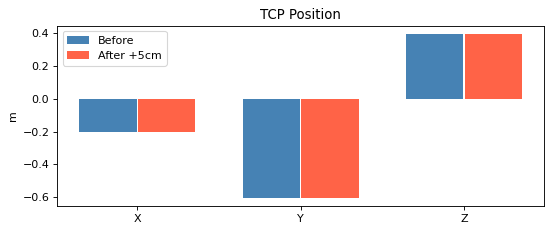

In [5]:
node.spin(5)
home = node.tcp.copy()
v0   = poses.pose_mtrx_to_vec(home)
print(f'HOME  x={v0[0]:.4f}  y={v0[1]:.4f}  z={v0[2]:.4f}')

# Move 5 cm up then return
tgt = home.copy(); tgt[2, 3] += 0.05
node.move(tgt, spd=0.05)
time.sleep(0.4); node.spin(5)
v1 = poses.pose_mtrx_to_vec(node.tcp)
print(f'UP    x={v1[0]:.4f}  y={v1[1]:.4f}  z={v1[2]:.4f}  dZ={(v1[2]-v0[2])*1000:.1f}mm')
node.move(home, spd=0.05)
print('Home.')

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(3)
ax.bar(x - .18, v0[:3], .35, label='Before',  color='steelblue')
ax.bar(x + .18, v1[:3], .35, label='After +5cm', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(['X', 'Y', 'Z'])
ax.set_ylabel('m'); ax.set_title('TCP Position'); ax.legend()
plt.tight_layout(); plt.show()

---
## 2. Gripper Control

Open     pos=103.6mm  force=0.000N  temp=34.5C
50mm     pos=49.7mm  force=0.000N  temp=34.5C
Closed   pos=-4.4mm  force=2.226N  temp=35.0C


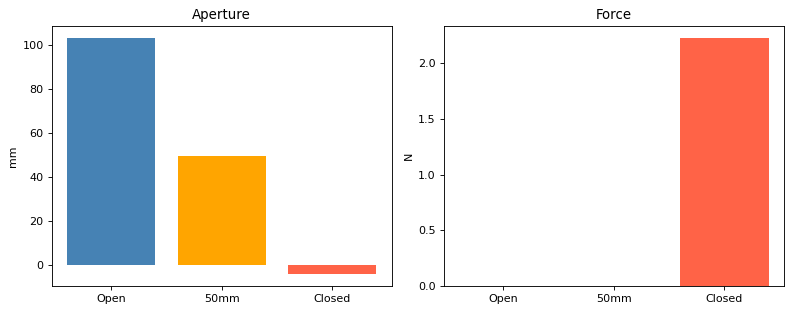

In [6]:
node.open_g();             time.sleep(0.6); node.spin(8); s0 = node.gs
node.set_force(5.)
node.set_pos(50.);         time.sleep(1.2); node.spin(8); s1 = node.gs
node.set_force(8.)
node.close_g();            time.sleep(2.5); node.spin(8); s2 = node.gs
node.open_g()

for lbl, s in [('Open', s0), ('50mm', s1), ('Closed', s2)]:
    if s:
        print(f'{lbl:<8} pos={s.position:.1f}mm  force={s.force:.3f}N  temp={s.temperature:.1f}C')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
states = ['Open', '50mm', 'Closed']
cols   = ['steelblue', 'orange', 'tomato']
a1.bar(states, [s.position if s else 0 for s in [s0, s1, s2]], color=cols)
a1.set_ylabel('mm'); a1.set_title('Aperture')
a2.bar(states, [s.force if s else 0 for s in [s0, s1, s2]], color=cols)
a2.set_ylabel('N');  a2.set_title('Force')
plt.tight_layout(); plt.show()

---
## 3. Poll Cameras

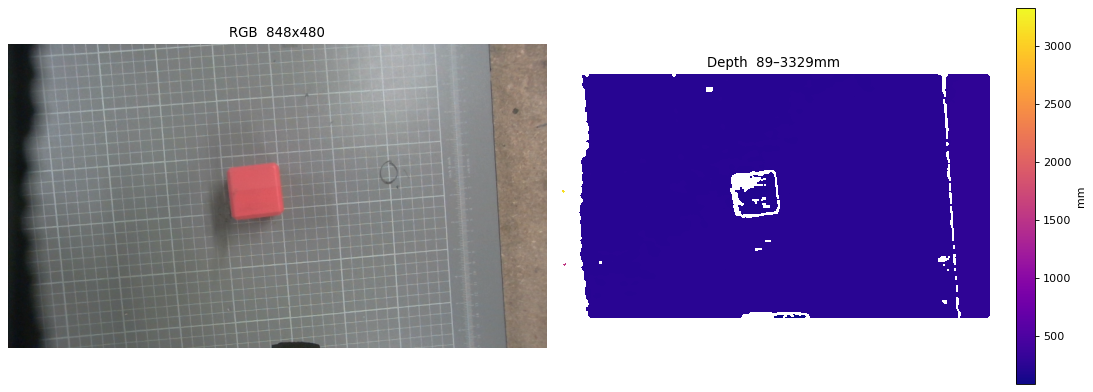

In [7]:
node.spin(12)
color = node.color.copy()
depth = node.depth.copy()

d = depth.astype(float); d[d == 0] = np.nan
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(color); a1.set_title(f'RGB  {color.shape[1]}x{color.shape[0]}'); a1.axis('off')
im = a2.imshow(d, cmap='plasma'); plt.colorbar(im, ax=a2, label='mm')
a2.set_title(f'Depth  {np.nanmin(d):.0f}–{np.nanmax(d):.0f}mm'); a2.axis('off')
plt.tight_layout(); plt.show()

---
## 4. Object Detection
### 4a. ViT — OWL-ViT

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

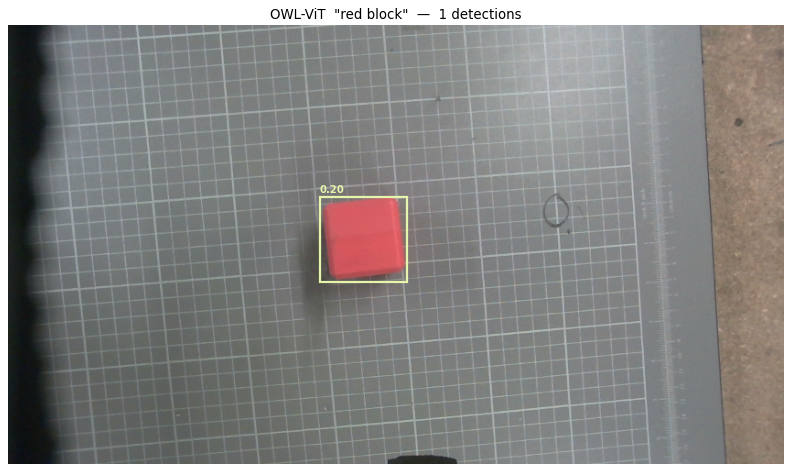

In [8]:
try:
    import torch
    from PIL import Image as PIL_Image
    from transformers import OwlViTProcessor, OwlViTForObjectDetection

    proc = OwlViTProcessor.from_pretrained('google/owlvit-base-patch32')
    mdl  = OwlViTForObjectDetection.from_pretrained('google/owlvit-base-patch32').eval()
    inp  = proc(text=[[OBJECT, f'a {OBJECT}']], images=PIL_Image.fromarray(color),
                return_tensors='pt')
    with torch.no_grad():
        out = mdl(**inp)
    # post_process is on the image_processor, not the wrapper
    results = proc.image_processor.post_process_object_detection(
        out, threshold=0.05, target_sizes=torch.tensor([color.shape[:2]]))[0]
    vb = results['boxes'].numpy()
    vs = results['scores'].numpy()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(color)
    for b, s in zip(vb, vs):
        x1, y1, x2, y2 = b
        c = plt.cm.YlGn(float(s))
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, lw=2, ec=c, fc='none'))
        ax.text(x1, y1-5, f'{s:.2f}', color=c, fontsize=9, fontweight='bold')
    ax.set_title(f'OWL-ViT  "{OBJECT}"  —  {len(vb)} detections'); ax.axis('off')
    plt.tight_layout(); plt.show()

except ImportError as e:
    print(f'SKIP: {e}  — run: pip install transformers torch')

### 4b. VLM — Gemini: Auto-Detect vs Specified

Auto-detect: "red cube"  |  Using: "red block"


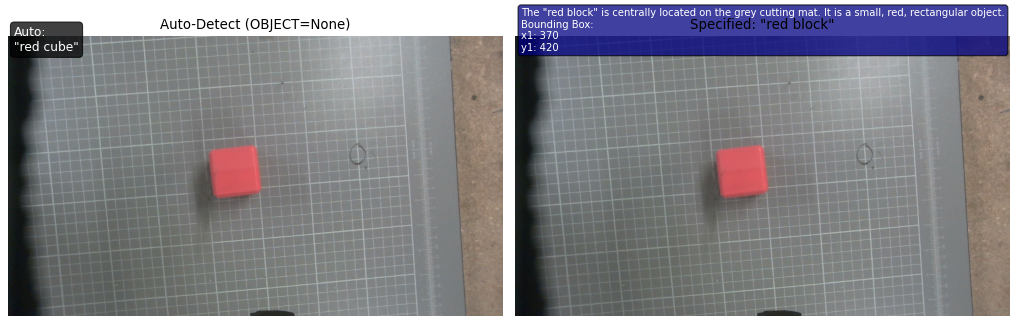

In [9]:
_, buf = cv2.imencode('.jpg', cv2.cvtColor(color, cv2.COLOR_RGB2BGR))
gc = genai.Client(api_key=GEMINI_KEY)

# Auto-detect: ask Gemini to name the main object
r_auto = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=buf.tobytes(), mime_type='image/jpeg'),
        'What is the main graspable object in this image? Reply 2-4 words only, no punctuation.'
    ])
auto_obj = r_auto.text.strip().lower()
auto_obj = ' '.join(auto_obj.split()[:4])
ACTIVE   = OBJECT if OBJECT else auto_obj
print(f'Auto-detect: "{auto_obj}"  |  Using: "{ACTIVE}"')

# Specified: ask for bounding box
r_spec = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=[
        gtypes.Part.from_bytes(data=buf.tobytes(), mime_type='image/jpeg'),
        f'Locate "{ACTIVE}": describe position and give bounding box x1,y1,x2,y2. Graspable yes/no.'
    ])
lines = [l for l in r_spec.text.strip().split('\n') if l.strip()][:4]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(color)
a1.text(10, 25, f'Auto:\n"{auto_obj}"', color='white', fontsize=11,
        bbox=dict(boxstyle='round', fc='black', alpha=0.75))
a1.set_title('Auto-Detect (OBJECT=None)'); a1.axis('off')
a2.imshow(color)
a2.text(10, 25, '\n'.join(lines), color='white', fontsize=9,
        bbox=dict(boxstyle='round', fc='navy', alpha=0.75))
a2.set_title(f'Specified: "{ACTIVE}"'); a2.axis('off')
plt.tight_layout(); plt.show()

### 4c. SAM3 — Socket (Warm)

Socket  1.28s  score=0.932  mask_px=6807


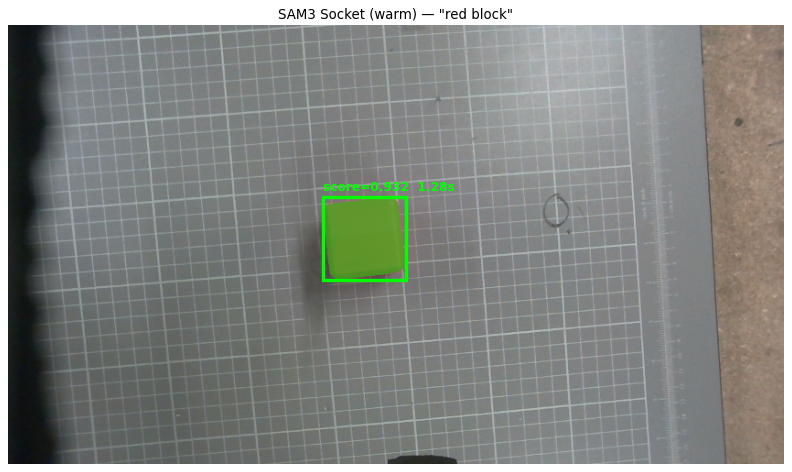

In [10]:
def sam3_query(img_rgb, query, sock_path=SAM3_SOCK):
    tmp = tempfile.mktemp(suffix='.jpg')
    cv2.imwrite(tmp, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    try:
        with _sock.socket(_sock.AF_UNIX, _sock.SOCK_STREAM) as s:
            s.connect(sock_path)
            s.sendall((json.dumps({'image': tmp, 'query': query}) + '\n').encode())
            raw = b''
            while True:
                chunk = s.recv(65536)
                if not chunk: break
                raw += chunk
        d = json.loads(raw.decode().strip())
        if 'error' in d: raise RuntimeError(d['error'])
        boxes  = np.array(d['boxes'],  dtype=float)
        scores = np.array(d['scores'], dtype=float)
        mask   = None
        if d.get('mask_b64') and len(boxes) > 0:
            raw2 = base64.b64decode(d['mask_b64'])
            h, w = d['mask_shape']
            mask = np.frombuffer(raw2, dtype=np.uint8).reshape(h, w).astype(bool)
        return boxes, scores, mask
    finally:
        if os.path.exists(tmp): os.unlink(tmp)

t0 = time.time()
sb, ss, sm = sam3_query(color, ACTIVE)
t_sock = time.time() - t0
best = int(np.argmax(ss)) if len(ss) > 0 else 0
print(f'Socket  {t_sock:.2f}s  score={ss[best]:.3f}  mask_px={sm.sum() if sm is not None else 0}')

best_boxes = sb; best_scores = ss; best_mask = sm

vis = color.copy()
if sm is not None:
    vis[sm] = (vis[sm] * .45 + np.array([0, 200, 0]) * .55).astype(np.uint8)
x1, y1, x2, y2 = sb[best].astype(int)
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(vis)
ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=3, ec='lime', fc='none'))
ax.text(x1, y1-8, f'score={ss[best]:.3f}  {t_sock:.2f}s', color='lime', fontsize=11, fontweight='bold')
ax.set_title(f'SAM3 Socket (warm) — "{ACTIVE}"'); ax.axis('off')
plt.tight_layout(); plt.show()

### 4d. SAM3 — Cold Start

Killing warm server to free VRAM...
Waiting 8s for CUDA to release...
Starting cold...
Loaded in 14s
Infer  1.24s  score=0.932


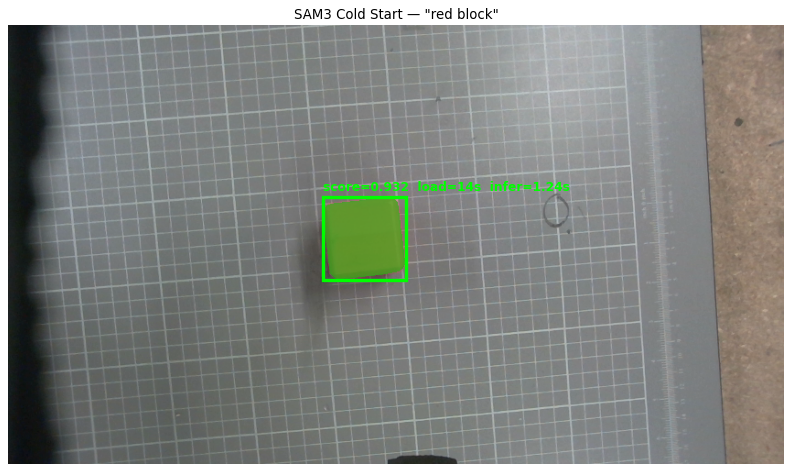


Restarting warm server...
Warm server ready after 14s


In [11]:
COLD_SOCK = '/tmp/sam3_cold.sock'

# Kill warm server to free VRAM, then load cold
print('Killing warm server to free VRAM...')
subprocess.run('pkill -9 -f sam3_infer', shell=True)
subprocess.run(f'rm -f {COLD_SOCK} /tmp/sam3.sock', shell=True)
print('Waiting 8s for CUDA to release...'); time.sleep(8)

print('Starting cold...')
t1 = time.time()
cold_proc = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket', COLD_SOCK],
    stdout=open('/tmp/log_sam3cold.txt', 'w'), stderr=subprocess.STDOUT)

cold_ok = False; t_load = t_infer = 0
cb, cs, cm = np.zeros((0,4)), np.array([]), None
for i in range(90):
    time.sleep(1)
    if os.path.exists(COLD_SOCK):
        t_load = time.time()-t1; cold_ok = True
        print(f'Loaded in {t_load:.0f}s'); break
    if cold_proc.poll() is not None:
        print('Crashed:'); print(open('/tmp/log_sam3cold.txt').read()[-400:]); break
    if (i+1) % 15 == 0: print(f'  {i+1}s...')

if cold_ok:
    t2 = time.time()
    cb, cs, cm = sam3_query(color, ACTIVE, COLD_SOCK)
    t_infer = time.time()-t2
    best2 = int(np.argmax(cs)) if len(cs) > 0 else 0
    print(f'Infer  {t_infer:.2f}s  score={cs[best2]:.3f}')

    vis = color.copy()
    if cm is not None:
        vis[cm] = (vis[cm]*.45 + np.array([0,200,0])*.55).astype(np.uint8)
    x1,y1,x2,y2 = cb[best2].astype(int)
    fig, ax = plt.subplots(figsize=(10,6))
    ax.imshow(vis)
    ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=3,ec='lime',fc='none'))
    ax.text(x1,y1-8,f'score={cs[best2]:.3f}  load={t_load:.0f}s  infer={t_infer:.2f}s',
            color='lime',fontsize=11,fontweight='bold')
    ax.set_title(f'SAM3 Cold Start — "{ACTIVE}"'); ax.axis('off')
    plt.tight_layout(); plt.show()

# Restart warm server for downstream cells
cold_proc.terminate()
subprocess.run(f'rm -f {COLD_SOCK}', shell=True)
print('\nRestarting warm server...')
PROCS['sam3'] = subprocess.Popen(
    [SAM3_PY, SAM3_SCR, '--socket'],
    stdout=open('/tmp/log_sam3.txt','w'), stderr=subprocess.STDOUT)
for i in range(90):
    time.sleep(1)
    if os.path.exists(SAM3_SOCK): print(f'Warm server ready after {i+1}s'); break
    if PROCS['sam3'].poll() is not None: print('Crashed'); break
    if (i+1) % 15 == 0: print(f'  {i+1}s...')

---
## 5. Segmented Point Cloud

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Raw 5398 pts  →  clean 5259 pts


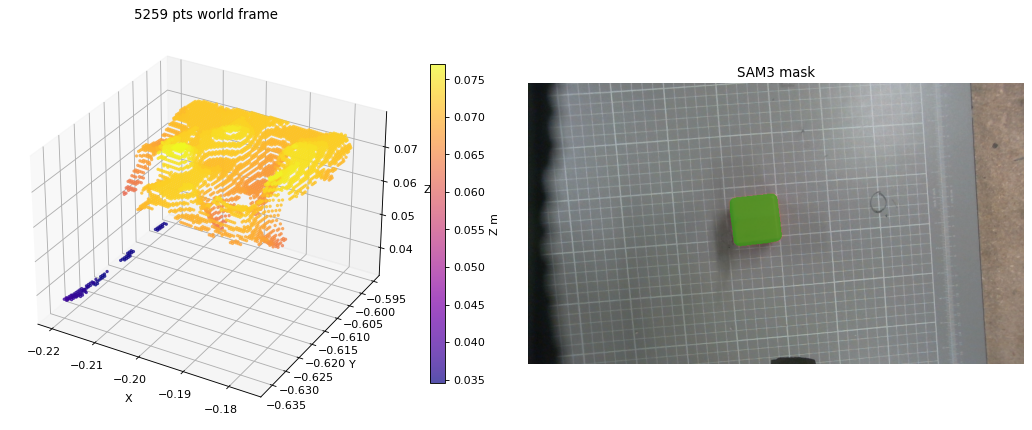

In [12]:
node.spin(5)
snap_color  = node.color.copy()
snap_depth  = node.depth.copy()
snap_tcp    = node.tcp.copy()
snap_ci     = node.caminfo

# Re-query SAM3 if we lost the mask from the previous cell
if best_mask is None or not best_mask.any():
    print('Re-querying SAM3...')
    best_boxes, best_scores, best_mask = sam3_query(snap_color, ACTIVE)

pts_raw, pcd_raw = build_segmented_pcd(
    best_mask, snap_depth, snap_ci.k, snap_tcp, _TCP_TO_CAM)
pcd_cln, pts_cln = denoise_pcd(pcd_raw)
print(f'Raw {len(pts_raw)} pts  →  clean {len(pts_cln)} pts')

fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(121, projection='3d')
sc = ax.scatter(pts_cln[:, 0], pts_cln[:, 1], pts_cln[:, 2],
                c=pts_cln[:, 2], cmap='plasma', s=4, alpha=.7)
plt.colorbar(sc, ax=ax, label='Z m', shrink=.7)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'{len(pts_cln)} pts world frame')
ax2 = fig.add_subplot(122)
vis = snap_color.copy()
if best_mask is not None:
    vis[best_mask] = (vis[best_mask] * .4 + np.array([0, 180, 0]) * .6).astype(np.uint8)
ax2.imshow(vis); ax2.set_title('SAM3 mask'); ax2.axis('off')
plt.tight_layout(); plt.show()

---
## 6. 3D Centroid / 6D Pose

Pixel  : (388, 233)
Depth  : 204.0 mm
Camera : [-0.016 -0.002  0.204]
World  : x=-0.1969  y=-0.6149  z=0.0722 m


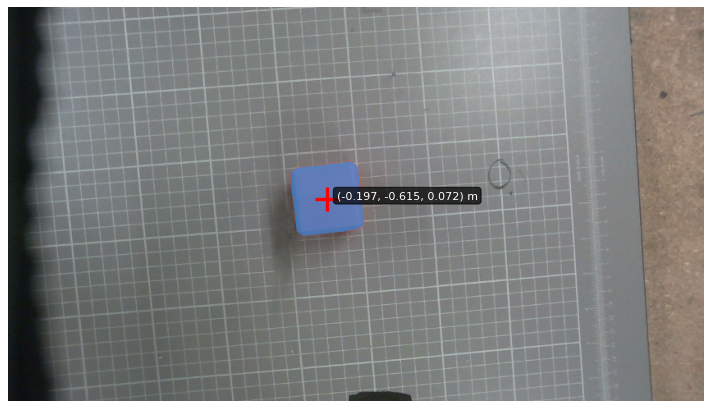

In [13]:
if best_mask is not None and best_mask.any():
    ys, xs = np.where(best_mask)
    u, v   = int(xs.mean()), int(ys.mean())
    valid  = snap_depth[best_mask].astype(float)
    valid  = valid[valid > 0]
else:
    h, w = snap_depth.shape
    u, v = w // 2, h // 2
    valid = np.array([])

dm = float(np.median(valid)) / 1000. if len(valid) > 0 else 0.
fx, fy = snap_ci.k[0], snap_ci.k[4]
cx, cy = snap_ci.k[2], snap_ci.k[5]
p_cam   = np.array([(u - cx) * dm / fx, (v - cy) * dm / fy, dm])
T       = snap_tcp @ _TCP_TO_CAM
p_world = (T @ np.array([*p_cam, 1.]))[:3]

print(f'Pixel  : ({u}, {v})')
print(f'Depth  : {dm*1000:.1f} mm')
print(f'Camera : {p_cam}')
print(f'World  : x={p_world[0]:.4f}  y={p_world[1]:.4f}  z={p_world[2]:.4f} m')

fig, ax = plt.subplots(figsize=(9, 6))
vis = snap_color.copy()
if best_mask is not None:
    vis[best_mask] = (vis[best_mask] * .45 + np.array([0, 150, 255]) * .55).astype(np.uint8)
ax.imshow(vis)
ax.plot(u, v, 'r+', ms=22, mew=3)
ax.text(u + 12, v, f'({p_world[0]:.3f}, {p_world[1]:.3f}, {p_world[2]:.3f}) m',
        color='white', fontsize=10, bbox=dict(boxstyle='round', fc='black', alpha=.7))
ax.axis('off'); plt.tight_layout(); plt.show()

---
## 7. PCA + Gripper Alignment

Extent  major=53.7mm  minor=62.2mm  normal=41.3mm
Grasp angle:   46.0 deg
Auto offset:   10 mm  (height/4, clamped 5-15mm)


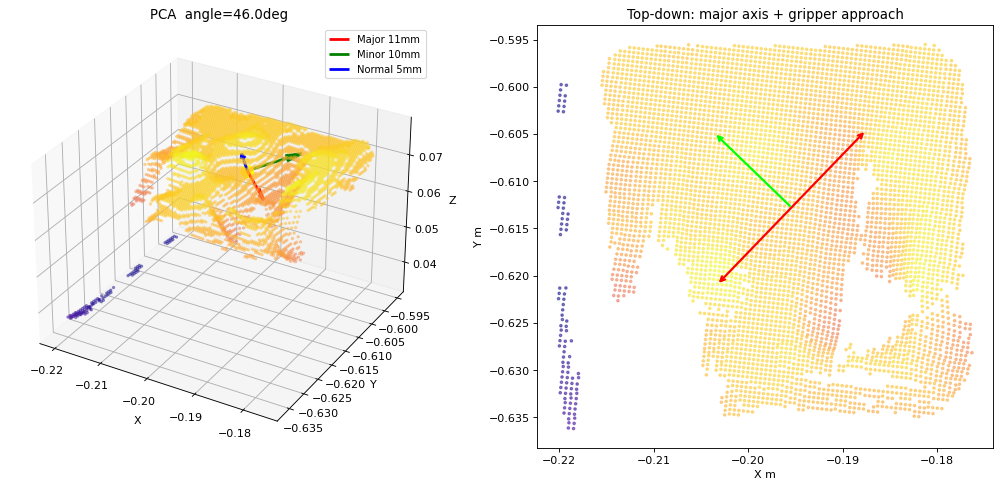

In [14]:
pca = analyse_pcd(pts_cln)
cen = pca['centroid']
ext = pca['extent_m']
ang = pca['grasp_angle_deg']
obj_height = ext[2]
auto_offset = float(np.clip(obj_height / 4., 0.005, 0.015))

print(f'Extent  major={ext[0]*1e3:.1f}mm  minor={ext[1]*1e3:.1f}mm  normal={ext[2]*1e3:.1f}mm')
print(f'Grasp angle:   {ang:.1f} deg')
print(f'Auto offset:   {auto_offset*1e3:.0f} mm  (height/4, clamped 5-15mm)')

ptc  = pts_cln - cen
ev, evec = np.linalg.eigh(np.cov(ptc.T))
idx  = np.argsort(ev)[::-1]; evec = evec[:, idx]; sc = np.sqrt(np.abs(ev[idx]))

fig = plt.figure(figsize=(13, 6))
ax  = fig.add_subplot(121, projection='3d')
ax.scatter(pts_cln[:, 0], pts_cln[:, 1], pts_cln[:, 2],
           c=pts_cln[:, 2], cmap='plasma', s=4, alpha=.4)
for i, (lbl, col) in enumerate(zip(['Major', 'Minor', 'Normal'], ['red', 'green', 'blue'])):
    vec = evec[:, i] * sc[i]
    ax.quiver(*cen, *vec, color=col, label=f'{lbl} {sc[i]*1e3:.0f}mm', lw=2.5)
ax.scatter(*cen, color='yellow', s=120, zorder=5)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'PCA  angle={ang:.1f}deg'); ax.legend(fontsize=9)

ax2 = fig.add_subplot(122)
ax2.scatter(pts_cln[:, 0], pts_cln[:, 1], c=pts_cln[:, 2], cmap='plasma', s=5, alpha=.5)
t = np.radians(ang); L = sc[0]
ax2.annotate('', xy=(cen[0]+L*np.cos(t), cen[1]+L*np.sin(t)),
             xytext=(cen[0]-L*np.cos(t), cen[1]-L*np.sin(t)),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.annotate('', xy=(cen[0]+L*np.cos(t+np.pi/2), cen[1]+L*np.sin(t+np.pi/2)),
             xytext=cen[:2],
             arrowprops=dict(arrowstyle='->', color='lime', lw=2))
ax2.set_aspect('equal'); ax2.set_xlabel('X m'); ax2.set_ylabel('Y m')
ax2.set_title('Top-down: major axis + gripper approach')
plt.tight_layout(); plt.show()

---
## 8. Move Arm to Computed Pose

In [15]:
from pointcloud_utils import grasp_rotation_matrix

# Step 1: approach pose — move above object keeping CURRENT orientation
ap = home.copy()
ap[0, 3] = p_world[0]
ap[1, 3] = p_world[1]
ap[2, 3] = p_world[2] + APPROACH_H + GRIPPER_LEN

afz  = p_world[2] + APPROACH_H
gfz  = p_world[2] - auto_offset
drop = fingertip_drop(103.6, 0.)
gez  = gfz - drop

ok_a = afz >= HARD_FLOOR_Z
ok_g = gez >= HARD_FLOOR_Z
print(f'Approach fingertip z : {afz:.4f} m  {"OK" if ok_a else "FLOOR HIT"}')
print(f'Grasp effective z    : {gez:.4f} m  {"OK" if ok_g else "FLOOR HIT"}')
print(f'Safety check         : {"PASS" if ok_a and ok_g else "FAIL"}')

if ok_a and ok_g:
    node.unteach()

    # Move to approach (same orientation as home, just translated above object)
    print(f'\nMoving to approach (TCP z={ap[2,3]:.3f} m)...')
    node.move(ap, spd=0.08)
    time.sleep(0.5); node.spin(5)
    cur = poses.pose_mtrx_to_vec(node.tcp)
    print(f'At approach: x={cur[0]:.3f} y={cur[1]:.3f} z={cur[2]:.3f}')

    # Step 2: apply PCA rotation at approach height (same as real pipeline)
    R_grasp = grasp_rotation_matrix(ang)
    ap_rot = ap.copy()
    ap_rot[:3, :3] = R_grasp
    print(f'\nApplying PCA rotation ({ang:.1f} deg)...')
    node.move(ap_rot, spd=0.05)
    time.sleep(0.5); node.spin(5)
    cur2 = poses.pose_mtrx_to_vec(node.tcp)
    print(f'After rotation: x={cur2[0]:.3f} y={cur2[1]:.3f} z={cur2[2]:.3f}')

    node.move(home, spd=0.08); print('\nHome.')
else:
    print('Move skipped (safety).')

Approach fingertip z : 0.1722 m  OK
Grasp effective z    : 0.0409 m  OK
Safety check         : PASS

Moving to approach (TCP z=0.403 m)...
At approach: x=-0.200 y=-0.604 z=0.396

Applying PCA rotation (46.0 deg)...
After rotation: x=-0.197 y=-0.615 z=0.403

Home.


---
## 9. Gripper Tool Length

TCP flange z (command) = 0.4032 m
GRIPPER_LEN            = 0.231 m
Fingertip at approach  = 0.1722 m  (= TCP - 0.231)
Grasp fingertip        = 0.0619 m  (approach - auto_offset)
Arc drop at full close = 21.0 mm


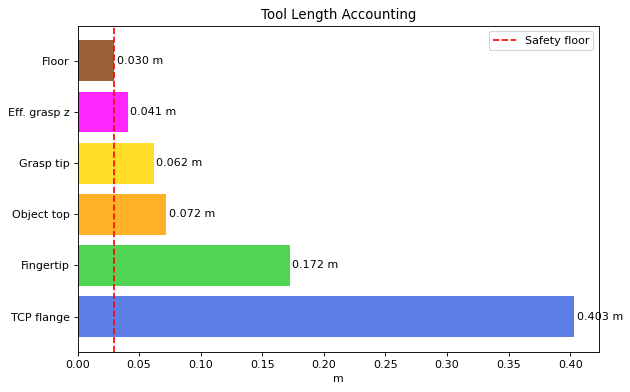

In [16]:
print(f'TCP flange z (command) = {ap[2,3]:.4f} m')
print(f'GRIPPER_LEN            = {GRIPPER_LEN:.3f} m')
print(f'Fingertip at approach  = {afz:.4f} m  (= TCP - {GRIPPER_LEN})')
print(f'Grasp fingertip        = {gfz:.4f} m  (approach - auto_offset)')
print(f'Arc drop at full close = {drop*1000:.1f} mm')

items = [
    ('TCP flange',    ap[2, 3], 'royalblue'),
    ('Fingertip',     afz,      'limegreen'),
    ('Object top',    p_world[2],'orange'),
    ('Grasp tip',     gfz,      'gold'),
    ('Eff. grasp z',  gez,      'magenta'),
    ('Floor',         HARD_FLOOR_Z, 'saddlebrown'),
]
fig, ax = plt.subplots(figsize=(8, 5))
for i, (lbl, z, col) in enumerate(items):
    ax.barh(i, z, color=col, alpha=.85)
    ax.text(z + .002, i, f'{z:.3f} m', va='center')
ax.set_yticks(range(len(items))); ax.set_yticklabels([it[0] for it in items])
ax.axvline(HARD_FLOOR_Z, color='red', ls='--', lw=1.5, label='Safety floor')
ax.set_xlabel('m'); ax.set_title('Tool Length Accounting'); ax.legend()
plt.tight_layout(); plt.show()

---
## 10. DeliGrasp Parameters (Gemini)

* This is a new grasp.
* In accordance with the user instruction, this grasp should be a secure pinch grasp for picking up the red block.
* This is a complete grasp.
* This grasp does not contain multiple grasps.
* This grasp is for an object with medium weight.
* The object has an approximate mass of 200 grams
* This grasp is for an object with low compliance.
* The object has an approximate spring constant of 5000 Newtons per meter.
* The gripper and object have an approximate friction coefficient of 0.7
* This grasp should set the goal aperture to 40 mm.
* If the gripper slips, this grasp should close an additional 5 mm.
* If the gripper slips, this grasp should increase the output force by 1 Newtons.
  mass           200 g
  mu             0.70
  k              5000 N/m
  aperture       40.0 mm
  init_force     2.803 N
  add_force      1.000 N
  closure        5.0 mm


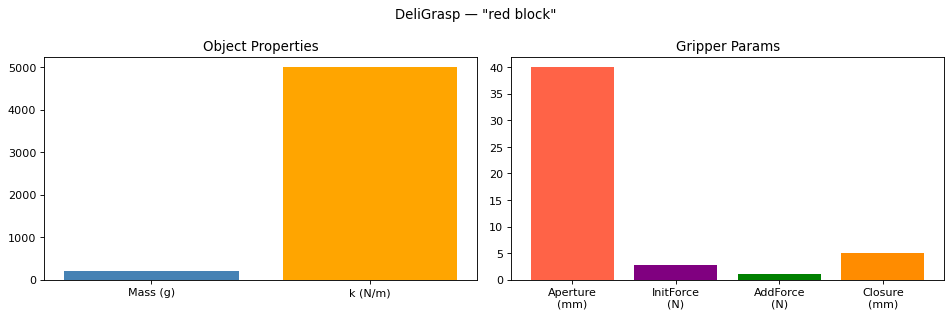

In [17]:
DG_SYS = (
    'Control a robot gripper. Max 16N min 0.15N, max aperture 105mm min 1mm.\n'
    '[start of description]\n'
    '* This is a new grasp.\n'
    '* In accordance with the user instruction, this grasp should be [GRASP_DESCRIPTION].\n'
    '* This is a complete grasp.\n'
    '* This grasp does not contain multiple grasps.\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} weight.\n'
    '* The object has an approximate mass of [PNUM] grams\n'
    '* This grasp is for an object with {CHOICE:[high,medium,low]} compliance.\n'
    '* The object has an approximate spring constant of [PNUM] Newtons per meter.\n'
    '* The gripper and object have an approximate friction coefficient of [PNUM]\n'
    '* This grasp should set the goal aperture to [PNUM] mm.\n'
    '* If the gripper slips, this grasp should close an additional [PNUM] mm.\n'
    '* If the gripper slips, this grasp should increase the output force by [PNUM] Newtons.\n'
    '[end of description]')

raw_dg = gc.models.generate_content(
    model='gemini-2.5-flash',
    contents=f'Pick up the {ACTIVE}.',
    config=gtypes.GenerateContentConfig(system_instruction=DG_SYS)).text
print(raw_dg)

NUM = r'([0-9]+(?:\.[0-9]+)?)'

def parse_dg(txt):
    # Use content between tags if present, otherwise use full response
    m = re.search(r'\[start of description\](.*?)\[end of description\]',
                  txt, re.DOTALL | re.IGNORECASE)
    b = m.group(1) if m else txt
    def g(pat):
        h = re.search(pat, b, re.IGNORECASE)
        return float(h.group(1)) if h else None
    mass = g(rf'mass of {NUM} grams')
    k    = g(rf'spring constant of {NUM} Newtons')
    mu   = g(rf'friction coefficient of {NUM}')
    ap2  = g(rf'goal aperture to {NUM} mm')
    cl   = g(rf'close an additional {NUM} mm')
    af   = g(rf'output force by {NUM} Newtons')
    fi   = min(16., max(0.15, (mass / 1000 * 9.81) / max(mu, 1e-6))) if mass and mu else 3.
    return dict(mass_g=mass, k=k, mu=mu, aperture_mm=ap2, closure_mm=cl,
                initial_force=fi, add_force=af or max(0.05, (cl or 5.) * (k or 100.) * .0001))

GP = parse_dg(raw_dg)
for key, val in [
    ('mass',        f"{GP['mass_g']:.0f} g"),
    ('mu',          f"{GP['mu']:.2f}"),
    ('k',           f"{GP['k']:.0f} N/m"),
    ('aperture',    f"{GP['aperture_mm']:.1f} mm"),
    ('init_force',  f"{GP['initial_force']:.3f} N"),
    ('add_force',   f"{GP['add_force']:.3f} N"),
    ('closure',     f"{GP['closure_mm']:.1f} mm"),
]:
    print(f'  {key:<14} {val}')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(['Mass (g)', 'k (N/m)'], [GP['mass_g'], GP['k']], color=['steelblue', 'orange'])
a1.set_title('Object Properties')
a2.bar(['Aperture\n(mm)', 'InitForce\n(N)', 'AddForce\n(N)', 'Closure\n(mm)'],
       [GP['aperture_mm'], GP['initial_force'], GP['add_force'], GP['closure_mm']],
       color=['tomato', 'purple', 'green', 'darkorange'])
a2.set_title('Gripper Params')
plt.suptitle(f'DeliGrasp — "{ACTIVE}"'); plt.tight_layout(); plt.show()

---
## 11. Adaptive Grasp (Slip Detection)

Close force = 5.0 N  |  slip threshold = 1.121 N
Attempt 1: force=5.00 N
  ap=30.6mm  F=2.366N  -> contact


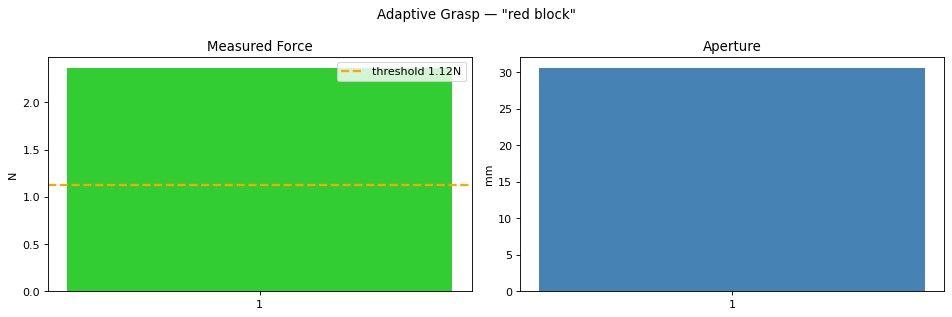

Result: contact  ap=30.6mm  F=2.366N  attempts=1


In [18]:
SLIP_RATIO   = 0.4
close_force  = max(GP['initial_force'], 5.)
slip_thresh  = max(0.15, GP['initial_force'] * SLIP_RATIO)
print(f'Close force = {close_force:.1f} N  |  slip threshold = {slip_thresh:.3f} N')

node.unteach()
node.open_g(); time.sleep(0.5)

log = []
cf  = close_force
for attempt in range(4):
    print(f'Attempt {attempt+1}: force={cf:.2f} N')
    node.set_force(cf)
    node.close_g(); time.sleep(3.5)
    for _ in range(8):
        rclpy.spin_once(node, timeout_sec=0.15)
    s = node.gs
    if s is None:
        print('  No gripper state received')
        break
    status = 'contact' if s.force >= slip_thresh else 'slip'
    print(f'  ap={s.position:.1f}mm  F={s.force:.3f}N  -> {status}')
    log.append({'attempt': attempt+1, 'force': s.force, 'ap': s.position, 'status': status})
    if status == 'contact':
        break
    if attempt < 3:
        cf = min(16., cf + GP['add_force'])

node.open_g()

if log:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    atts   = [str(x['attempt']) for x in log]
    cols   = ['limegreen' if x['status'] == 'contact' else 'tomato' for x in log]
    a1.bar(atts, [x['force'] for x in log], color=cols)
    a1.axhline(slip_thresh, color='orange', ls='--', lw=2, label=f'threshold {slip_thresh:.2f}N')
    a1.set_ylabel('N'); a1.set_title('Measured Force'); a1.legend()
    a2.bar(atts, [x['ap'] for x in log], color='steelblue')
    a2.set_ylabel('mm'); a2.set_title('Aperture')
    plt.suptitle(f'Adaptive Grasp — "{ACTIVE}"'); plt.tight_layout(); plt.show()
    last = log[-1]
    print(f'Result: {last["status"]}  ap={last["ap"]:.1f}mm  F={last["force"]:.3f}N  attempts={len(log)}')

---
## Shutdown

---
## 12. Full Pickup — End-to-End

=== Full Pickup ===
Object: "red block"
Snapshot OK
SAM3 detecting...
  score=0.939  mask_px=6768
  centroid=(-0.194,-0.584,0.072)  angle=21.1deg  offset=11mm
  depth centroid=(-0.196,-0.585,0.074)
Safety OK  approach_fz=0.174m  grasp_eff_z=0.041m

Approach...
PCA rotate...
Descend...
Grasping (force=5.0N  threshold=2.00N)...
  attempt 1: ap=30.6mm F=1.239N -> slip
  attempt 2: ap=30.1mm F=1.494N -> slip
  attempt 3: ap=29.7mm F=3.252N -> contact
Lifting...
Home...
Done — object released.


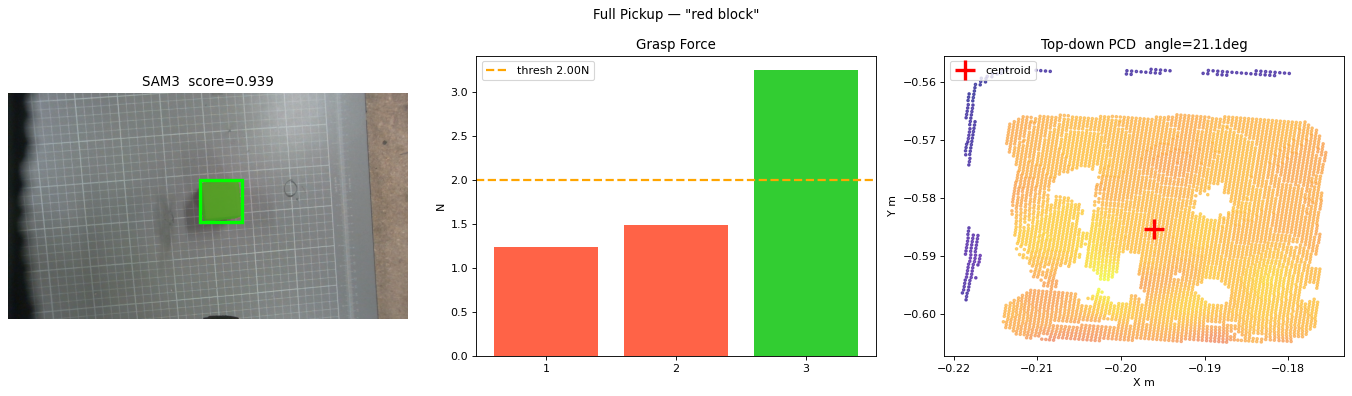


Result: contact  ap=29.7mm  F=3.252N  attempts=3


In [19]:
from pointcloud_utils import build_segmented_pcd, denoise_pcd, analyse_pcd, grasp_rotation_matrix
from magpie_control.gripper_arc import fingertip_drop

print('=== Full Pickup ===')
print(f'Object: "{ACTIVE}"')

# ── 1. Snapshot ──────────────────────────────────────────────────────────────
node.spin(8)
snap_color = node.color.copy()
snap_depth = node.depth.copy()
snap_tcp   = node.tcp.copy()
snap_ci    = node.caminfo
home_pick  = snap_tcp.copy()
print('Snapshot OK')

# ── 2. SAM3 detect ───────────────────────────────────────────────────────────
print('SAM3 detecting...')
det_boxes, det_scores, det_mask = sam3_query(snap_color, ACTIVE)
if len(det_scores) == 0 or det_mask is None:
    raise RuntimeError('SAM3: no detection')
best_i = int(np.argmax(det_scores))
print(f'  score={det_scores[best_i]:.3f}  mask_px={det_mask.sum()}')

# ── 3. Point cloud + PCA ─────────────────────────────────────────────────────
pts_raw, pcd_raw = build_segmented_pcd(det_mask, snap_depth, snap_ci.k, snap_tcp, _TCP_TO_CAM)
_, pts_cln       = denoise_pcd(pcd_raw)
if len(pts_cln) < 3:
    raise RuntimeError(f'Too few points after denoise: {len(pts_cln)}')
pca        = analyse_pcd(pts_cln)
cen        = pca['centroid']
ang        = pca['grasp_angle_deg']
obj_h      = pca['extent_m'][2]
grasp_off  = float(np.clip(obj_h / 4., 0.005, 0.015))
print(f'  centroid=({cen[0]:.3f},{cen[1]:.3f},{cen[2]:.3f})  angle={ang:.1f}deg  offset={grasp_off*1e3:.0f}mm')

# ── 4. Centroid from depth (fallback if PCA centroid is off) ─────────────────
ys, xs = np.where(det_mask)
u, v   = int(xs.mean()), int(ys.mean())
valid  = snap_depth[det_mask].astype(float); valid = valid[valid > 0]
dm     = float(np.median(valid)) / 1000.
fx, fy = snap_ci.k[0], snap_ci.k[4]
cx, cy = snap_ci.k[2], snap_ci.k[5]
p_cam  = np.array([(u-cx)*dm/fx, (v-cy)*dm/fy, dm])
T      = snap_tcp @ _TCP_TO_CAM
p_obj  = (T @ np.array([*p_cam, 1.]))[:3]
print(f'  depth centroid=({p_obj[0]:.3f},{p_obj[1]:.3f},{p_obj[2]:.3f})')

# ── 5. Safety check ──────────────────────────────────────────────────────────
afz  = p_obj[2] + APPROACH_H
gfz  = p_obj[2] - grasp_off
drop = fingertip_drop(103.6, 0.)
gez  = gfz - drop
assert afz >= HARD_FLOOR_Z, f'Approach fingertip {afz:.3f}m below floor'
assert gez >= HARD_FLOOR_Z, f'Grasp fingertip {gez:.3f}m below floor'
print(f'Safety OK  approach_fz={afz:.3f}m  grasp_eff_z={gez:.3f}m')

# ── 6. Build poses ───────────────────────────────────────────────────────────
ap = home_pick.copy()
ap[0, 3] = p_obj[0]; ap[1, 3] = p_obj[1]
ap[2, 3] = p_obj[2] + APPROACH_H + GRIPPER_LEN

R_grasp  = grasp_rotation_matrix(ang)
ap_rot   = ap.copy(); ap_rot[:3, :3] = R_grasp

grasp_pose = ap_rot.copy()
grasp_pose[2, 3] = gfz + GRIPPER_LEN

# ── 7. Execute ───────────────────────────────────────────────────────────────
node.unteach()
node.open_g(); time.sleep(0.5)

print('\nApproach...')
node.move(ap, spd=0.10)
time.sleep(0.4); node.spin(4)

print('PCA rotate...')
node.move(ap_rot, spd=0.05)
time.sleep(0.4); node.spin(4)

print('Descend...')
node.move(grasp_pose, spd=0.05)
time.sleep(0.5); node.spin(4)

# Adaptive grasp with slip detection
SLIP_RATIO  = 0.4
cf          = max(GP['initial_force'], 5.) if 'GP' in dir() else 5.
slip_thresh = max(0.15, cf * SLIP_RATIO)
print(f'Grasping (force={cf:.1f}N  threshold={slip_thresh:.2f}N)...')
grasp_log = []
for attempt in range(4):
    node.set_force(cf); node.close_g(); time.sleep(3.0)
    for _ in range(8): rclpy.spin_once(node, timeout_sec=0.15)
    s = node.gs
    if s is None: break
    status = 'contact' if s.force >= slip_thresh else 'slip'
    print(f'  attempt {attempt+1}: ap={s.position:.1f}mm F={s.force:.3f}N -> {status}')
    grasp_log.append({'a': attempt+1, 'ap': s.position, 'f': s.force, 'st': status})
    if status == 'contact': break
    cf = min(16., cf + (GP['add_force'] if 'GP' in dir() else 1.))

print('Lifting...')
node.move(ap_rot, spd=0.05); time.sleep(0.5); node.spin(4)
print('Home...')
node.move(home_pick, spd=0.10); time.sleep(0.5); node.spin(4)
node.open_g()
print('Done — object released.')

# ── 8. Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Detection
vis = snap_color.copy()
vis[det_mask] = (vis[det_mask]*.4 + np.array([0,200,0])*.6).astype(np.uint8)
x1,y1,x2,y2 = det_boxes[best_i].astype(int)
axes[0].imshow(vis)
axes[0].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,lw=3,ec='lime',fc='none'))
axes[0].set_title(f'SAM3  score={det_scores[best_i]:.3f}'); axes[0].axis('off')

# Grasp force log
if grasp_log:
    atts = [str(x['a']) for x in grasp_log]
    cols = ['limegreen' if x['st']=='contact' else 'tomato' for x in grasp_log]
    axes[1].bar(atts, [x['f'] for x in grasp_log], color=cols)
    axes[1].axhline(slip_thresh, color='orange', ls='--', lw=2, label=f'thresh {slip_thresh:.2f}N')
    axes[1].set_ylabel('N'); axes[1].set_title('Grasp Force'); axes[1].legend()

# PCD
axes[2].scatter(pts_cln[:,0], pts_cln[:,1], c=pts_cln[:,2], cmap='plasma', s=5, alpha=.6)
axes[2].plot(*p_obj[:2], 'r+', ms=18, mew=3, label='centroid')
axes[2].set_xlabel('X m'); axes[2].set_ylabel('Y m')
axes[2].set_title(f'Top-down PCD  angle={ang:.1f}deg'); axes[2].legend()

plt.suptitle(f'Full Pickup — "{ACTIVE}"'); plt.tight_layout(); plt.show()

result = grasp_log[-1] if grasp_log else {}
print(f'\nResult: {result.get("st","?")}  ap={result.get("ap",0):.1f}mm  F={result.get("f",0):.3f}N  attempts={len(grasp_log)}')

In [ ]:
import signal
for n, p in PROCS.items():
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
    except Exception:
        p.terminate()
    print(f'stopped {n}')
PROCS.clear()
try:
    node.destroy_node()
    rclpy.shutdown()
except Exception:
    pass
print('Done.')